# Comparing edge samplers, action priors & the angle reward — one context

A single **context initialisation** (one curated decision point), one planner **seed**, and
the **`TCenterAngleReward`** (centered **and** upright, `combine="weighted_sum"`). We build one
MCTS tree per configuration and compare them with the tools we've implemented:

* the reward **`TCenterAngleReward`** + `score_t_centered_angle` (heading-resolved),
* the diversity descriptor **`THeadingDescriptor`** (up/down-resolved pose),
* the tree diagnostics **`compute_tree_metrics`** and in-model **`compute_baselines`**,
* the annotation viz **`annotate_t`** (+ a heading arrow).

**What we vary** (everything else fixed):
* `edge_mode` — `imagine` (joint) vs `two_stage` vs `autoregressive` (step-by-step),
* `action_prior` — `normal` vs `uniform` (std-matched flow prior),
* `action_noise` / `action_noise_dist` — extra noise added to each policy action (autoregressive only).

> **Cost note.** The autoregressive sampler does `2·H` primitive calls per edge, so its trees are
> much slower than `imagine`. The base config below is deliberately modest; scale it up once you've
> eyeballed the comparison.

## Setup — model, reward, descriptor, helpers

In [1]:
%load_ext autoreload
%autoreload 2
import time, math
from pathlib import Path
import numpy as np, torch, cv2
import pandas as pd
import matplotlib.pyplot as plt
try:
    import mediapy
except Exception:
    mediapy = None

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
resolution = (256, 256)
print('device:', device)

device: cuda:0


In [2]:
# Load the world model with the study's loader (same hydra compose the sweep uses).
from dreamerv4uwm.planning.experiments.study.model import (
    load_world_model, make_decode_fn, model_dims)

DYN_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
TOK_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'
DATA_DIR = '/home/mim-server/datasets/pushT/h5/play'

denoiser, tokenizer, mcfg = load_world_model(
    dynamics_ckpt=DYN_CKPT, tokenizer_ckpt=TOK_CKPT,
    config_name='dynamics/pushT-large', overrides=['denoiser.horizon_aware=false'],
    device=device)
decode = make_decode_fn(tokenizer, device)          # lat (B,T,N,D) -> video (B,T,3,H,W) float[0,1]
dims = model_dims(denoiser)
N_LAT, D_LAT, N_ACT = dims['num_latent_tokens'], dims['latent_dim'], dims['n_actions']
print('model loaded |', dims)

/home/mim-server/miniconda3/envs/dreamerv4uwm/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT-large': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


model loaded | {'num_noise_levels': 128, 'num_latent_tokens': 256, 'latent_dim': 32, 'n_actions': 2}


In [3]:
# --- reward (angle, weighted_sum), diversity descriptor (heading), planner + metrics ---
from dreamerv4uwm.planning import rollout as R
from dreamerv4uwm.planning.mcts import MCTS, PlanConfig
from dreamerv4uwm.planning.reward import (TCenterAngleReward, score_t_centered,
                                          score_t_centered_angle, annotate_t)
from dreamerv4uwm.planning.experiments.study.descriptors import THeadingDescriptor
from dreamerv4uwm.planning.experiments.study.metrics import compute_tree_metrics
from dreamerv4uwm.planning.experiments.study.baselines import compute_baselines
from dreamerv4uwm.planning.experiments.study.analysis import schema

# angle-reward kwargs (must match between the reward and the annotation readout)
ANGLE_KW = dict(center_xy=(0.5, 0.5), sigma=0.25,
                target_heading_deg=-90.0, sigma_heading_deg=25.0,
                combine='weighted_sum', w_center=0.5, w_orient=0.5)

reward_T   = TCenterAngleReward(decode_fn=decode, **ANGLE_KW)
descriptor = THeadingDescriptor(decode_fn=decode, dup_eps=0.06, orient_weight=0.5,
                                center_xy=(0.5, 0.5), sigma=0.25)
print('reward:', type(reward_T).__name__, '| descriptor:', type(descriptor).__name__)

reward: TCenterAngleReward | descriptor: THeadingDescriptor


In [4]:
# --- decode / annotate viz helpers ---
def frame_rgb(lat_1frame):
    # (1,1,N,D) latent -> (H,W,3) uint8 RGB
    v = decode(lat_1frame)[0, 0]
    return (v.permute(1, 2, 0).clamp(0, 1) * 255).to(torch.uint8).cpu().numpy()

def annotate_angle(rgb, d):
    # annotate_t (T contour + centroid + the ANGLE reward) plus a heading arrow
    # pointing toward the crossbar (the 'up' of an upright T)
    out = annotate_t(rgb, d)
    if d.get('found') and np.isfinite(d.get('heading_deg', np.nan)):
        cx, cy = d['centroid']; H, W = out.shape[:2]
        L = 0.20 * np.sqrt(H * W); phi = np.deg2rad(d['heading_deg'])
        p2 = (int(cx + L * np.cos(phi)), int(cy + L * np.sin(phi)))
        cv2.arrowedLine(out, (int(round(cx)), int(round(cy))), p2, (255, 140, 0), 2, tipLength=0.3)
    return out

def show_plan(ctx_z, roll_z, name):
    # filmstrip (context | plan) annotated with the angle reward + heading arrow,
    # plus the per-frame reward curve marking the start and the peak
    if roll_z is None:
        print(f'{name}: no plan'); return
    full = torch.cat([ctx_z, roll_z], 1)
    frames, rew = [], []
    for t in range(full.shape[1]):
        rgb = frame_rgb(full[:, t:t + 1]); s, d = score_t_centered_angle(rgb, **ANGLE_KW)
        frames.append(annotate_angle(rgb, d)); rew.append(s)
    rew = np.array(rew); Tc = ctx_z.shape[1]; peak_t = int(Tc + np.argmax(rew[Tc:]))
    fig = plt.figure(figsize=(15, 5.6))
    gs = fig.add_gridspec(2, 8, height_ratios=[1.2, 1.0], hspace=0.3, wspace=0.12)
    samp = np.unique(np.concatenate([[Tc - 1], np.linspace(Tc, full.shape[1] - 1, 7, dtype=int)]))[:8]
    for k, t in enumerate(samp):
        ax = fig.add_subplot(gs[0, k]); ax.imshow(frames[t]); ax.axis('off')
        tag = 'start' if t == Tc - 1 else ('PEAK' if t == peak_t else f't={t-Tc+1}')
        ax.set_title(f'{tag}\nR={rew[t]:.2f}', fontsize=9,
                     color=('C2' if t == peak_t else ('C3' if t == Tc - 1 else 'k')))
    axc = fig.add_subplot(gs[1, :5])
    axc.plot(range(full.shape[1]), rew, 'o-', ms=4)
    axc.axvspan(0, Tc - 1, color='grey', alpha=0.15); axc.axvline(Tc - 0.5, color='grey', ls='--')
    axc.scatter([Tc - 1], [rew[Tc - 1]], c='C3', s=80, zorder=5, label=f'start R={rew[Tc-1]:.2f}')
    axc.scatter([peak_t], [rew[peak_t]], c='C2', s=110, marker='*', zorder=5, label=f'peak R={rew[peak_t]:.2f}')
    axc.set_xlabel('frame (context | plan)'); axc.set_ylabel('TCenterAngleReward')
    axc.legend(fontsize=8, loc='lower right'); axc.grid(alpha=.3)
    axb = fig.add_subplot(gs[1, 5]); axb.imshow(frames[Tc - 1]); axb.axis('off'); axb.set_title('START', color='C3', fontsize=9)
    axp = fig.add_subplot(gs[1, 6:]); axp.imshow(frames[peak_t]); axp.axis('off'); axp.set_title('PEAK', color='C2', fontsize=9)
    fig.suptitle(f'{name}  (orange arrow = T heading; green cross = image centre)', y=0.99)
    plt.show()
    if mediapy is not None:
        mediapy.show_video([np.ascontiguousarray(f) for f in frames] + [frames[peak_t]] * 6, fps=6)

## Pick one context

We use the curated init set (`pushT_curated.yaml`) and take a **single** decision point. Change
`INIT_IDX` to try another. The last context frame is shown with the angle reward's readout: the
green cross is the image centre, the yellow outline the segmented T, the orange arrow its heading.

Train split: 64694 windows from 11 episodes
40 curated inits (reward_kind=angle, combine=weighted_sum)
init_id=12 window=33809 t0=28 label='bottom-right, far, T-right (6deg)'


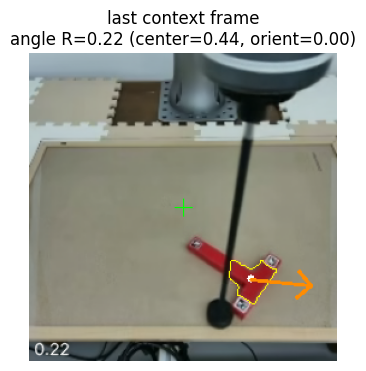

start angle-reward = 0.221 | heading = 6 deg


In [5]:
import dreamerv4uwm
from omegaconf import OmegaConf
from dreamerv4uwm.planning.experiments.study.data import make_dataset, load_curated_contexts

# the curated init file lives inside the study package (robust to the kernel cwd)
INIT_YAML = (Path(dreamerv4uwm.__file__).parent /
             'planning/experiments/study/config/inits/pushT_curated.yaml')
spec = OmegaConf.to_container(OmegaConf.load(INIT_YAML), resolve=True)
d = spec['dataset']
dataset = make_dataset(DATA_DIR, window_size=int(d.get('window_size', 64)),
                       stride=int(d.get('stride', 1)), split=str(d.get('split', 'train')),
                       train_fraction=float(d.get('train_fraction', 0.9)),
                       split_seed=int(d.get('split_seed', 123)),
                       shuffle_windows=bool(d.get('shuffle_windows', False)))
inits = load_curated_contexts(dataset, tokenizer, spec, device=device, n_actions=N_ACT, reward_fn=None)
print(f'{len(inits)} curated inits (reward_kind={spec.get("reward_kind")}, combine={spec.get("reward_combine")})')

INIT_IDX = 12
init = inits[INIT_IDX]
cz, ca = init['ctx_z'], init['ctx_a']
print(f"init_id={init['init_id']} window={init['window_idx']} t0={init['t0']} label={init.get('label')!r}")

s0, d0 = score_t_centered_angle(frame_rgb(cz[:, -1:]), **ANGLE_KW)
plt.figure(figsize=(4, 4)); plt.imshow(annotate_angle(frame_rgb(cz[:, -1:]), d0)); plt.axis('off')
plt.title(f'last context frame\nangle R={s0:.2f} (center={d0["center"]:.2f}, orient={d0["orient"]:.2f})')
plt.show()
print(f'start angle-reward = {s0:.3f} | heading = {d0.get("heading_deg"):.0f} deg')

## The configurations to compare

One `PlanConfig` per row, all sharing the same modest base; only the sampler / prior / noise knobs
differ. Same planner `SEED`, same context, same `TCenterAngleReward`.

In [6]:
SEED = 0
BASE = dict(horizon=12, branching=4, edge_mode='imagine', sim_horizon=12, sim_rollouts=2,
            n_iterations=16, c_ucb=0.5, gamma=0.98, n_min=0, max_depth=2, K_steps=6,
            ctx_noise=0.5, ctx_noise_honest=True, action_temp=1.0, action_prior='normal',
            action_noise=0.0, action_noise_dist='normal', max_ctx=16)

CONFIGS = [
    ('imagine - normal prior',  {}),
    ('imagine - uniform prior', dict(action_prior='uniform')),
    ('two_stage',               dict(edge_mode='two_stage')),
    ('autoregressive',          dict(edge_mode='autoregressive')),
    ('AR + noise N(0.3)',       dict(edge_mode='autoregressive', action_noise=0.3, action_noise_dist='normal')),
    ('AR + noise U(0.3)',       dict(edge_mode='autoregressive', action_noise=0.3, action_noise_dist='uniform')),
]
print(f'{len(CONFIGS)} configs, seed={SEED}, base horizon={BASE["horizon"]} n_iter={BASE["n_iterations"]}')

6 configs, seed=0, base horizon=12 n_iter=16


In [7]:
# metrics we want to compare (a readable subset of compute_tree_metrics + baselines)
METRIC_KEYS = ['n_nodes', 'max_depth', 'root_bci', 'root_action_div', 'root_outcome_div',
               'root_found_frac', 'val_std', 'q_margin', 'exploit_explore_ratio',
               'visit_entropy', 'commit_top1']
BASELINE_KEYS = ['delta_over_root', 'g_1shot_fair', 'g_shootN_fair']

def run_config(name, override, n_random=8):
    # build one tree; return (row, planner, out, plan_z)
    cfg = PlanConfig(**{**BASE, **override})
    planner = MCTS(denoiser, reward_T, cfg, seed=SEED)
    t = time.time(); out = planner.plan(cz, ca); secs = time.time() - t
    plan_z = (torch.cat([e.z_seq for e in out['best_path']], 0)[None] if out['best_path'] else None)
    tree_peak = float(reward_T(plan_z[0]).max()) if plan_z is not None else float('nan')
    m  = compute_tree_metrics(planner, descriptor, result=out)
    bl = compute_baselines(denoiser, reward_T, cz, ca, cfg, tree_peak=tree_peak,
                           n_random=n_random, seed=SEED + 100003)
    row = dict(name=name, edge_mode=cfg.edge_mode, action_prior=cfg.action_prior,
               action_noise=cfg.action_noise, action_noise_dist=cfg.action_noise_dist,
               plan_secs=round(secs, 1), n_forward=out['n_forward'], tree_peak=tree_peak,
               **{k: bl.get(k) for k in BASELINE_KEYS},
               **{k: m.get(k) for k in METRIC_KEYS})
    print(f"  {name:24s} {secs:5.1f}s  peak={tree_peak:.3f}  g_1shot_fair={bl.get('g_1shot_fair'):+.3f}  "
          f"root_bci={m.get('root_bci')}  root_action_div={m.get('root_action_div'):.2f}")
    return row, planner, out, plan_z

## Run the trees + metrics table

In [8]:
rows, results = [], {}
print(f'start angle-reward = {s0:.3f}\n')
for name, ov in CONFIGS:
    row, planner, out, plan_z = run_config(name, ov)
    rows.append(row); results[name] = dict(planner=planner, out=out, plan_z=plan_z)

df = pd.DataFrame(rows).set_index('name')
df

start angle-reward = 0.221

  imagine - normal prior    41.5s  peak=0.754  g_1shot_fair=-0.008  root_bci=0.75  root_action_div=0.03
  imagine - uniform prior   41.4s  peak=0.754  g_1shot_fair=-0.008  root_bci=0.75  root_action_div=0.03
  two_stage                 60.4s  peak=0.957  g_1shot_fair=+0.196  root_bci=0.75  root_action_div=0.04
  autoregressive           741.4s  peak=0.746  g_1shot_fair=-0.016  root_bci=0.75  root_action_div=0.01
  AR + noise N(0.3)        741.3s  peak=0.751  g_1shot_fair=-0.010  root_bci=0.75  root_action_div=2.06
  AR + noise U(0.3)        741.3s  peak=0.751  g_1shot_fair=-0.011  root_bci=0.75  root_action_div=2.11


,edge_mode,action_prior,action_noise,action_noise_dist,plan_secs,n_forward,tree_peak,delta_over_root,g_1shot_fair,g_shootN_fair,...,max_depth,root_bci,root_action_div,root_outcome_div,root_found_frac,val_std,q_margin,exploit_explore_ratio,visit_entropy,commit_top1
name,,,,,,,,,,,,,,,,,,,,,
imagine - normal prior,imagine,normal,0.0,normal,41.5,21,0.753866,0.532943,-0.007836,-0.226776,...,2.0,0.75,0.030435,0.004140,1.0,0.366314,2.134273,1.321001,0.834868,0.5625
imagine - uniform prior,imagine,uniform,0.0,normal,41.4,21,0.753866,0.532943,-0.007836,-0.226095,...,2.0,0.75,0.030575,0.002607,1.0,0.362339,2.138187,1.335493,0.834868,0.5625
two_stage,two_stage,normal,0.0,normal,60.4,36,0.957289,0.736366,0.195587,-0.023353,...,2.0,0.75,0.035536,0.031350,1.0,1.346308,2.298556,0.506677,0.496696,0.8125
autoregressive,autoregressive,normal,0.0,normal,741.4,504,0.745935,0.525012,-0.015767,-0.234707,...,2.0,0.75,0.014422,0.005705,1.0,0.003448,0.204409,120.736106,1.000000,0.2500
AR + noise N(0.3),autoregressive,normal,0.3,normal,741.3,504,0.751487,0.530564,-0.010215,-0.229155,...,2.0,0.75,2.056931,0.005534,1.0,0.001881,0.641771,221.316997,1.000000,0.2500
AR + noise U(0.3),autoregressive,normal,0.3,uniform,741.3,504,0.751195,0.530272,-0.010507,-0.229447,...,2.0,0.75,2.114266,0.005633,1.0,0.001237,0.087676,336.442601,1.000000,0.2500


In [9]:
# what each shown metric means (single source of truth: analysis/schema.py)
for c in ['tree_peak'] + BASELINE_KEYS + METRIC_KEYS:
    print(f'  {c:22s} {schema.DESCRIPTIONS.get(c, "")}')

  tree_peak              best single-frame reward over the frames of the RETURNED PLAN
  delta_over_root        tree_peak - root_reward: did the plan improve on the start state at all?
  g_1shot_fair           tree_peak - oneshot_fair_peak: planning gain over a no-search rollout of the SAME lookahead (horizon*max_depth, re-conditioned). (FAIR HEADLINE)
  g_shootN_fair          tree_peak - shootN_fair_peak: search gain over fair random shooting at the same lookahead
  n_nodes                total nodes in the tree
  max_depth              cap on tree depth
  root_bci               branch-collapse index at the ROOT expansion (the headline collapse number)
  root_action_div        action diversity at the ROOT expansion
  root_outcome_div       T-pose outcome diversity at the ROOT expansion
  root_found_frac        fraction of root children where a valid T was detected
  val_std                std of the root children's mean values; ->0 = children indistinguishable
  q_margin              

## Compare the configs

`tree_peak` / `delta_over_root` / `g_*_fair` = **did it plan well** (higher is better).
`root_bci` (->1 = collapsed), `root_action_div` / `root_outcome_div`, `val_std` = **the mechanism**
(how diverse the root edges were and whether the values separated them). `n_forward` = **cost**.

> Reminder: the baselines are always built with the `imagine` sampler, so `g_*_fair` under
> `two_stage` / `autoregressive` reflects the sampler choice too, not search alone.

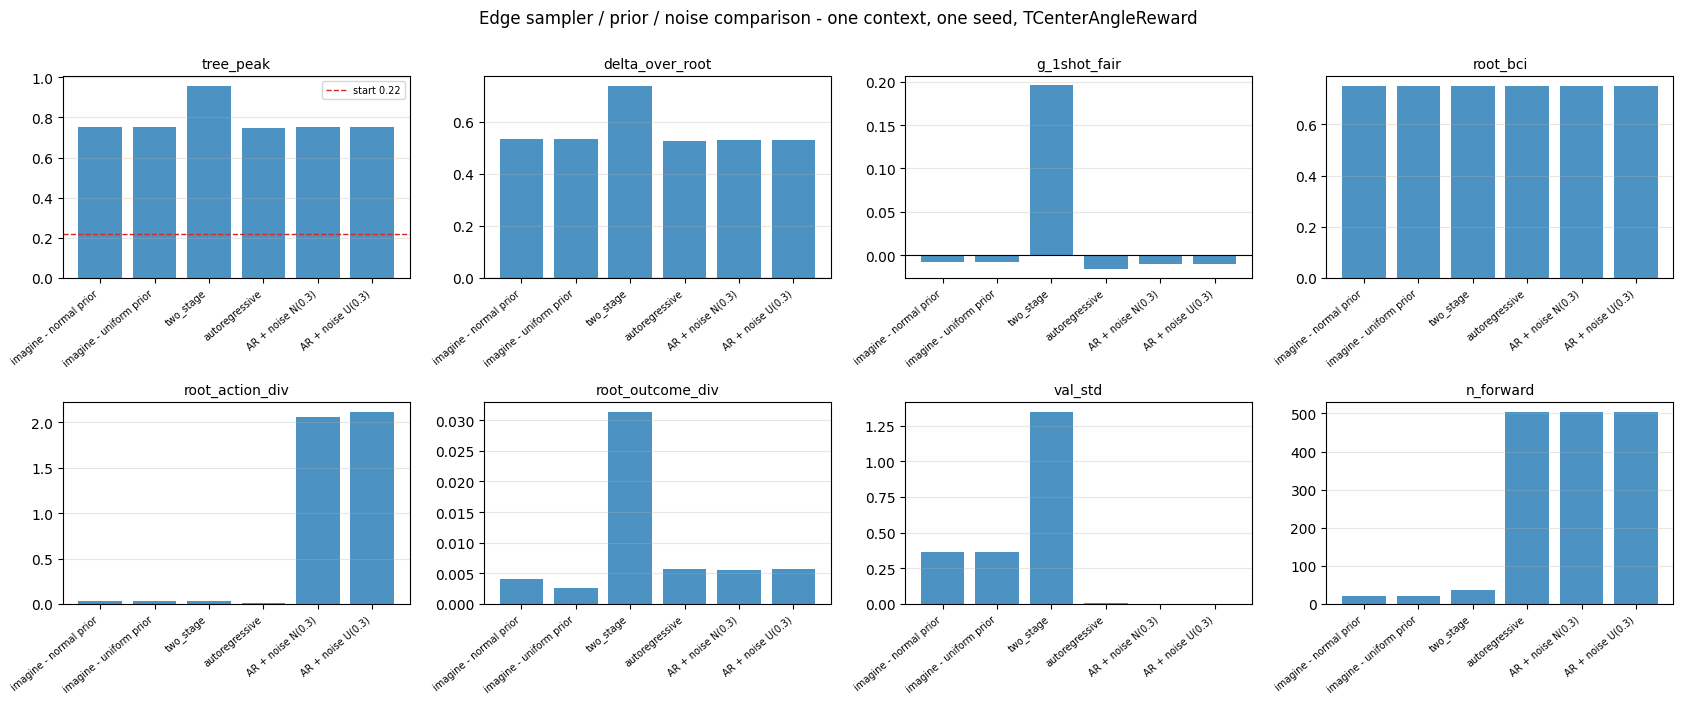

In [10]:
PANELS = ['tree_peak', 'delta_over_root', 'g_1shot_fair', 'root_bci',
          'root_action_div', 'root_outcome_div', 'val_std', 'n_forward']
names = list(df.index)
x = np.arange(len(names))
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, col in zip(axes.ravel(), PANELS):
    vals = df[col].astype(float).values
    ax.bar(x, vals, color='C0', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=40, ha='right', fontsize=7)
    ax.set_title(col, fontsize=10); ax.grid(alpha=.3, axis='y')
    if col == 'tree_peak':
        ax.axhline(s0, color='C3', ls='--', lw=1, label=f'start {s0:.2f}'); ax.legend(fontsize=7)
    if col in BASELINE_KEYS:
        ax.axhline(0, color='k', lw=0.8)
fig.suptitle('Edge sampler / prior / noise comparison - one context, one seed, TCenterAngleReward', y=1.0)
plt.tight_layout(); plt.show()

## Visualize each plan

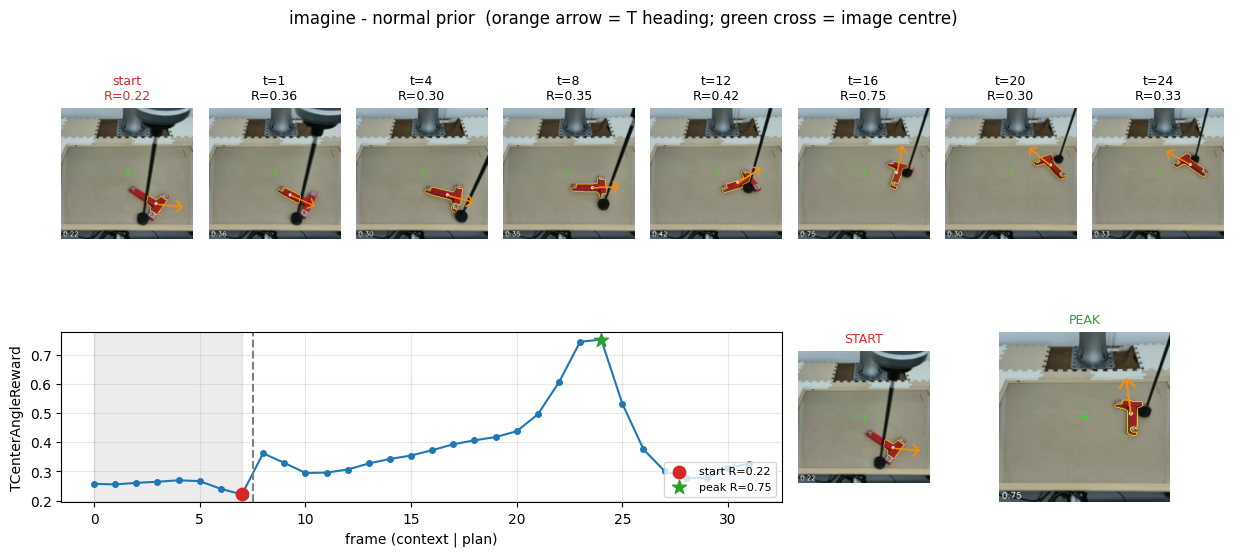

This browser does not support the video tag.


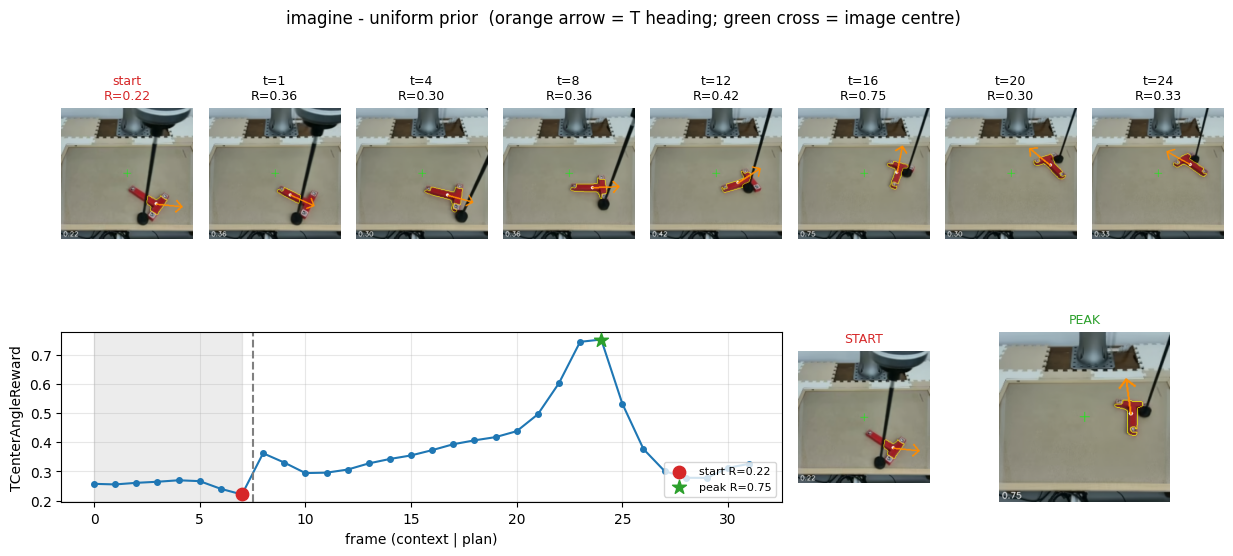

This browser does not support the video tag.


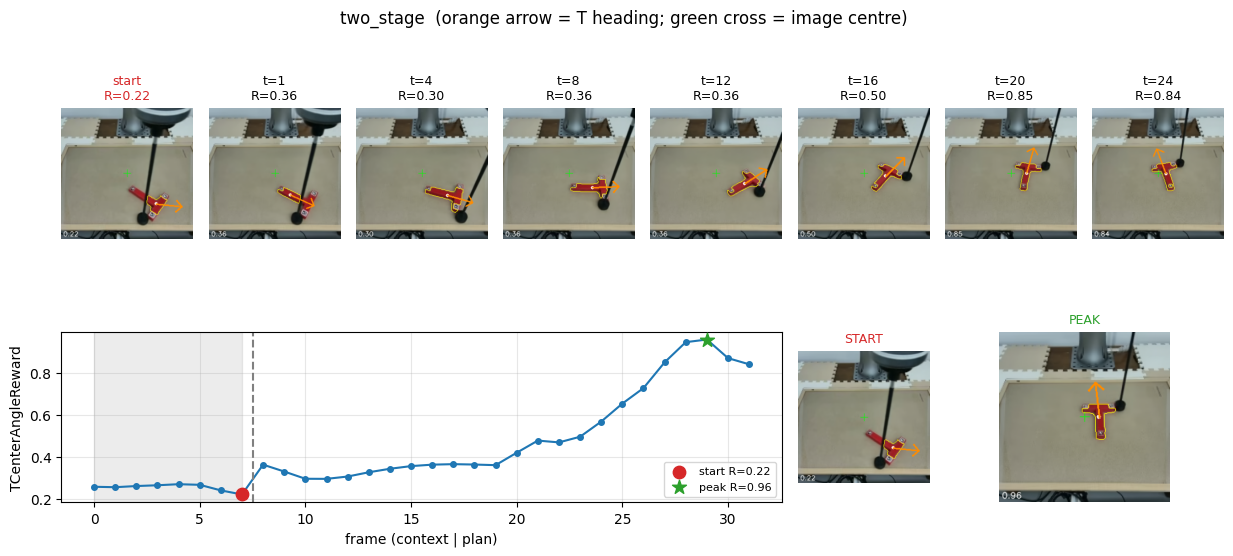

This browser does not support the video tag.


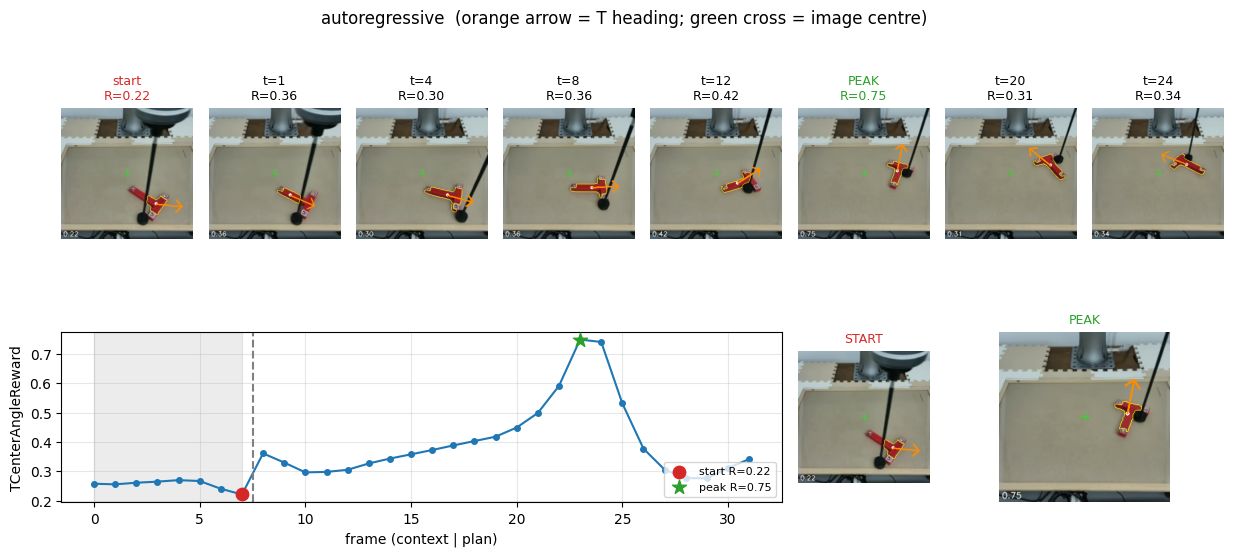

This browser does not support the video tag.


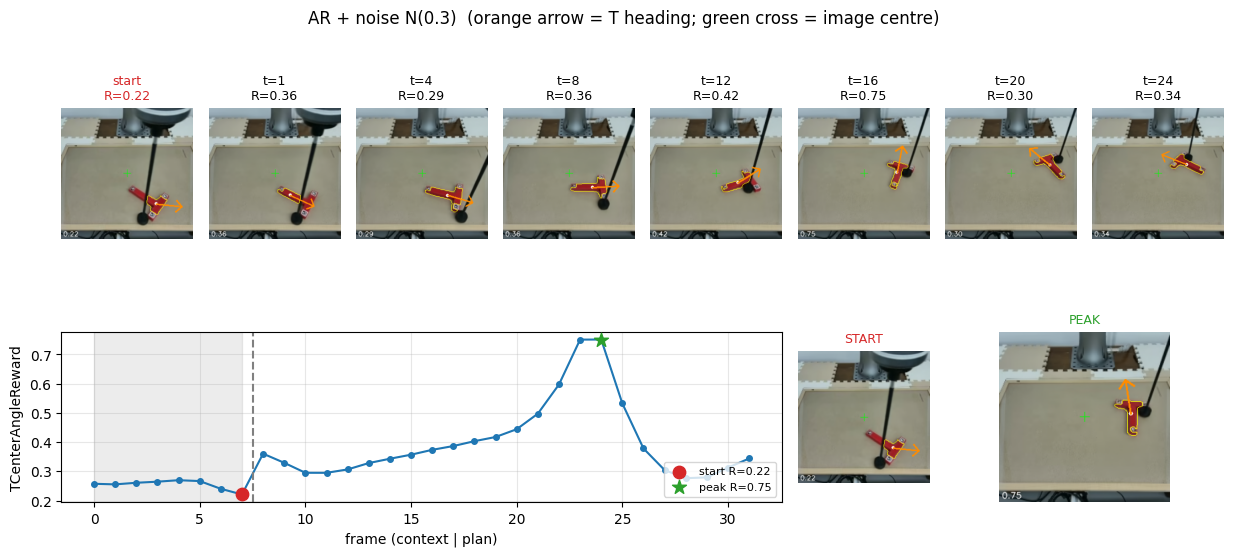

This browser does not support the video tag.


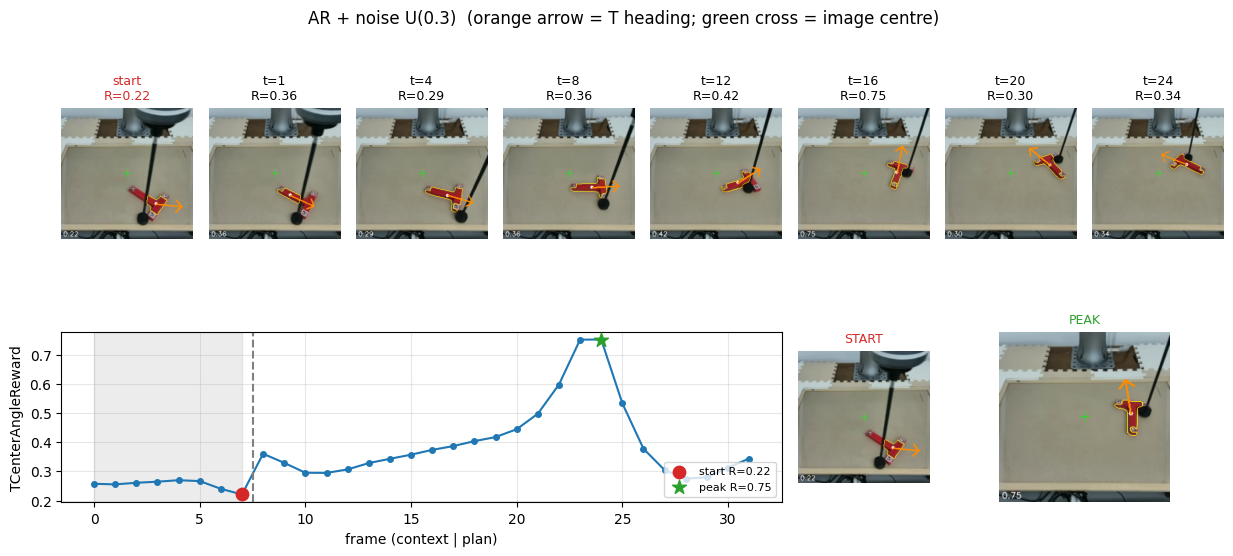

This browser does not support the video tag.


In [11]:
for name, _ in CONFIGS:
    show_plan(cz, results[name]['plan_z'], name)

### Notes / next steps
* This is **one** context and **one** seed - treat differences as anecdotal until repeated over
  seeds/inits (that is what the sweep does; here we just eyeball mechanisms and viz).
* To study the autoregressive action noise properly, set `edge_mode='autoregressive'` and vary
  `action_noise` across a few values, and/or raise `BASE['horizon']` / `n_iterations` (mind the cost).
* Swap `INIT_IDX` to a different curated decision point (e.g. an already-upright vs an inverted T).